In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("/content/Students suspicious behaviors detection dataset_V1.csv")

df.head()

,face_present,no_of_face,face_x,face_y,face_w,face_h,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,phone_conf,gaze_on_script,gaze_direction,gazePoint_x,gazePoint_y,pupil_left_x,pupil_left_y,pupil_right_x,pupil_right_y,label
0,1,1,262.579536,312.062903,151.787758,151.787567,307.918568,354.478884,373.059845,353.494949,...,0.0,1,center,336,325,304,348,368,354,0
1,1,1,260.704193,312.342424,154.607773,154.607735,305.797863,354.197273,372.084160,357.747831,...,0.0,1,center,345,324,304,348,369,354,0
2,1,1,264.240570,311.801834,148.079300,148.079195,304.438133,351.268072,368.618050,353.264036,...,0.0,1,center,336,325,304,348,368,354,0
3,1,1,262.811012,314.088278,151.014061,151.014175,304.091930,355.737219,369.532318,355.841103,...,0.0,1,center,339,333,304,349,368,355,0
4,1,1,269.176426,312.678709,148.739681,148.739605,310.720120,354.326448,374.389267,350.510445,...,0.0,1,center,377,313,316,351,378,355,0


In [3]:
print(df.shape)

df.info()

df.head()

(5500, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   face_present          5500 non-null   int64  
 1   no_of_face            5500 non-null   int64  
 2   face_x                5500 non-null   float64
 3   face_y                5500 non-null   float64
 4   face_w                5500 non-null   float64
 5   face_h                5500 non-null   float64
 6   left_eye_x            5500 non-null   float64
 7   left_eye_y            5500 non-null   float64
 8   right_eye_x           5500 non-null   float64
 9   right_eye_y           5500 non-null   float64
 10  nose_tip_x            5500 non-null   float64
 11  nose_tip_y            5500 non-null   float64
 12  mouth_x               5500 non-null   float64
 13  mouth_y               5500 non-null   float64
 14  face_conf             5500 non-null   float64
 15  hand_count

,face_present,no_of_face,face_x,face_y,face_w,face_h,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,phone_conf,gaze_on_script,gaze_direction,gazePoint_x,gazePoint_y,pupil_left_x,pupil_left_y,pupil_right_x,pupil_right_y,label
0,1,1,262.579536,312.062903,151.787758,151.787567,307.918568,354.478884,373.059845,353.494949,...,0.0,1,center,336,325,304,348,368,354,0
1,1,1,260.704193,312.342424,154.607773,154.607735,305.797863,354.197273,372.084160,357.747831,...,0.0,1,center,345,324,304,348,369,354,0
2,1,1,264.240570,311.801834,148.079300,148.079195,304.438133,351.268072,368.618050,353.264036,...,0.0,1,center,336,325,304,348,368,354,0
3,1,1,262.811012,314.088278,151.014061,151.014175,304.091930,355.737219,369.532318,355.841103,...,0.0,1,center,339,333,304,349,368,355,0
4,1,1,269.176426,312.678709,148.739681,148.739605,310.720120,354.326448,374.389267,350.510445,...,0.0,1,center,377,313,316,351,378,355,0


In [4]:
le = LabelEncoder()

df['head_pose'] = le.fit_transform(df['head_pose'])
df['gaze_direction'] = le.fit_transform(df['gaze_direction'])

In [5]:
X = df.drop('label', axis=1)

y = df['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [8]:
y_pred = dt.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.990909090909091


In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[569   7]
 [  3 521]]


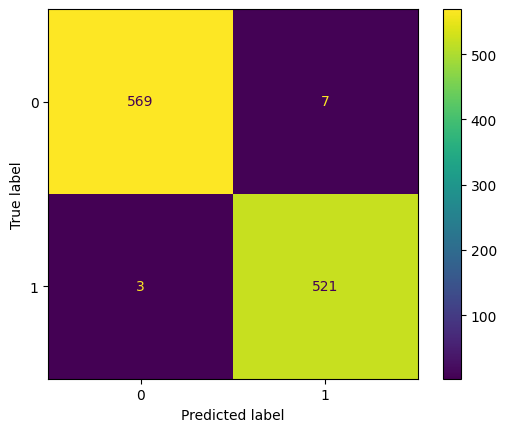

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot()

plt.show()

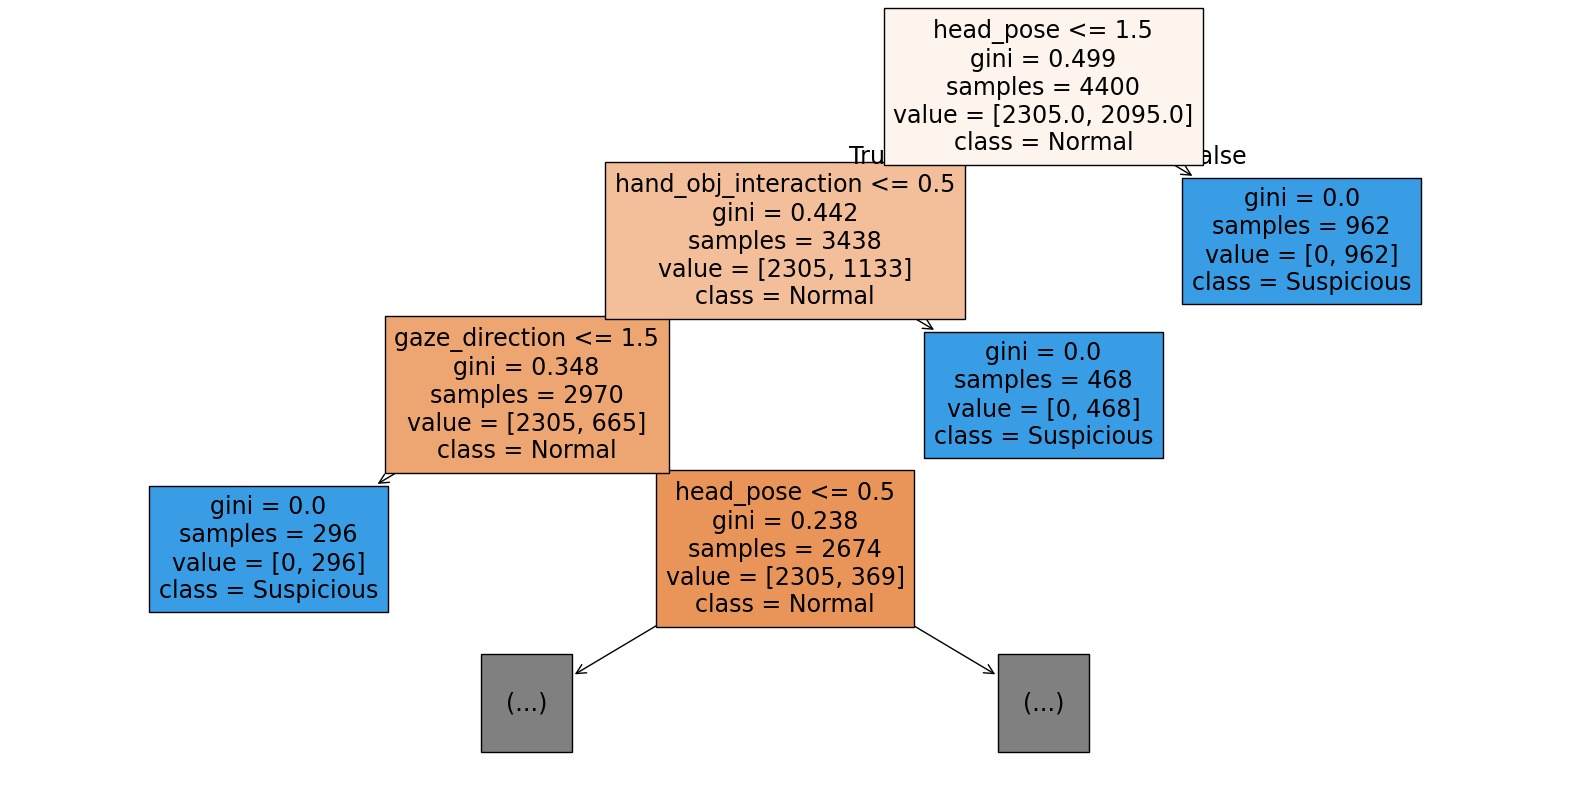

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    filled=True,
    max_depth=3,
    feature_names=X.columns,
    class_names=['Normal','Suspicious']
)

plt.show()

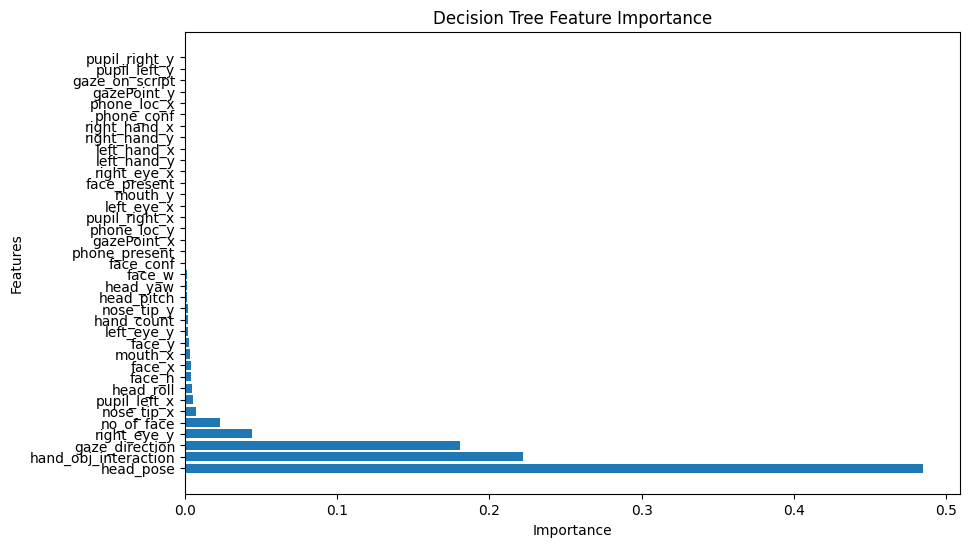

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Decision Tree Feature Importance')

plt.show()